# Data Science bootcamp
В данном ноутбуке представлено решение контеста на отбор [`Data Science bootcamp`](https://start.avito.ru/datascience-bootcamp) по направлению [`classic ml`](https://stepik.org/lesson/2589118/step/1).

## Участник
**Бондаренко Федор Алексеевич** (fedobondarenko@gmail.com, [GitHub](https://github.com/FedorProgrammer), [stepik](https://stepik.org/users/189216442/profile))

# Оглавление:
- [Подготовка окружения](#Подготовка-окружения)
    - [Скачивание зависимостей](#Скачивание-зависимостей)
    - [Конфигурация](#Конфигурация)
        - [Импорты](#Импорты)
        - [Параметры обучения](#Параметры-обучения)
    - [Воспроизводимость](#Воспроизводимость)
- [Обработка данных](#Обработка-данных)
    - [Загрузка данных](#Загрузка-данных-в-pandas.DataFrame)
    - [Примеры данных](#Примеры-данных)
    - [Характеристики данных](#Характеристики-данных)
        - [Типы данных](#Типы-данных)
        - [Распределение баланса классов](#Распределение-баланса-классов)
        - [Пропуски в данных](#Пропуски-в-данных)

## Подготовка окружения

### Скачивание зависимостей
Устанавливаем необходимые файлы:
1. датасет (трейн, тест, события);
2. модуль `metric.py`;
3. пример решения.

> В дальнейшем, данные для обучения будут браться из директории `data/`.

In [1]:
import zipfile
import urllib.request
from pathlib import Path

def download_challenge_data() -> None:
    '''Устанавливает данные по ссылке, что была опубликована на странице контеста
    '''
    data_path = Path("data")
    if not data_path.is_dir():
        zip_path = Path("challenge_data.zip")
        url = "https://stepik.org/media/attachments/lesson/2589118/bot_detection_challenge.zip"
        urllib.request.urlretrieve(url, zip_path)
        
        with zipfile.ZipFile(zip_path) as challenge_zip:
            challenge_zip.extractall(path=".")
        zip_path.unlink()
    else:
        print("Данные уже установлены")

download_challenge_data()

Данные уже установлены


### Конфигурация

#### Импорты 
Подключаем все необходимые библиотеки для: 
- обработки данных;
- обучения модели;
- оценки ее качества;
- визуализации.

In [2]:
import random

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import sklearn

import catboost as cb
import lightgbm as lgb

from metric import precision_at_recall

%matplotlib inline

#### Параметры обучения
Задаем основные параметры обучения

In [3]:
SEED = 42

N_SPLITS = 4
ITERATIONS = 1500

### Воспроизводимость
Делаем обучение воспроизводимым -- фиксируем сиды.

In [4]:
def set_global_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)

set_global_seed(SEED)
print(f"Глобальный сид установлен; его значение -- {SEED}")

Глобальный сид установлен; его значение -- 42


## Обработка данных

### Загрузка данных в pandas.DataFrame

In [5]:
train = pd.read_csv("data/train.csv", parse_dates=['cookie_created_at', 'window_start_ts', 'window_end_ts'])
test = pd.read_csv("data/test.csv", parse_dates=['cookie_created_at', 'window_start_ts', 'window_end_ts'])
events = pd.read_csv("data/events.csv.gz", parse_dates=['event_ts'])

print(train.shape, test.shape, events.shape)

(11091, 5) (4909, 4) (328905, 14)


### Примеры данных

In [6]:
train.sample(5)

,cookie_id,cookie_created_at,window_start_ts,window_end_ts,target
1891,ck_8df0e1700243310f,2026-04-07 07:17:48,2026-04-08,2026-04-09,0
9165,ck_4d70e8e03b078415,2026-02-24 18:14:14,2026-04-17,2026-04-18,0
3902,ck_eebaaa38fb01fa72,2026-01-19 04:48:21,2026-04-10,2026-04-11,0
10213,ck_1388b91f875a4fe2,2025-10-25 21:40:01,2026-04-18,2026-04-19,0
883,ck_d6cd2e957f758107,2026-03-08 14:25:06,2026-04-07,2026-04-08,0


In [7]:
test.sample(5)

,cookie_id,cookie_created_at,window_start_ts,window_end_ts
861,ck_962e65ab33b5c311,2026-04-18 17:27:47,2026-04-21,2026-04-22
2974,ck_501dcf1ead036d2b,2026-03-08 23:07:09,2026-04-24,2026-04-25
3963,ck_68250033717cd59e,2026-03-01 09:48:41,2026-04-25,2026-04-26
1774,ck_e914974cee1bccb1,2026-04-20 05:01:29,2026-04-22,2026-04-23
4360,ck_64eefec062592c43,2026-02-15 04:53:36,2026-04-26,2026-04-27


In [8]:
events.sample(5)

,cookie_id,event_ts,eid,event_name,platform,user_agent,item_id,item_category,item_location,seller_type,search_query,search_page,pointer_x,pointer_y
72257,ck_d026b2dc7227d214,2026-04-07 17:27:59,210,photo_swipe,WEB,Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:1...,1034301.0,zhivotnye,moskva,pro,NaN,NaN,NaN,NaN
150048,ck_e1a21ba313896b9b,2026-04-08 01:47:31,100,search_results_view,Web,Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:1...,NaN,mebel,novosibirsk,NaN,кровать 160х200,1.0,NaN,NaN
294032,ck_16c9b12c2561cab9,2026-04-17 23:53:28,301,contact_chat_open,Android,Mozilla/5.0 (Linux; Android 12; SM-A515F) Appl...,1021852.0,telefony,cheboksary,pro,NaN,NaN,NaN,NaN
157557,ck_9e84edadcce8c071,2026-04-08 11:53:26,400,favorite_add,ANDROID,Mozilla/5.0 (Linux; Android 14; Pixel 6) Apple...,1051814.0,bytovaya_tehnika,moskva,private,NaN,NaN,NaN,NaN
279786,ck_f409ff994a210601,2026-04-25 17:37:27,200,item_view,Android,Mozilla/5.0 (Linux; Android 12; Pixel 6) Apple...,1034262.0,hobbi,ekaterinburg,private,NaN,NaN,NaN,NaN


### Характеристики данных

#### Типы данных

In [9]:
train.dtypes

cookie_id                       str
cookie_created_at    datetime64[us]
window_start_ts      datetime64[us]
window_end_ts        datetime64[us]
target                        int64
dtype: object

In [10]:
events.dtypes

cookie_id                   str
event_ts         datetime64[us]
eid                       int64
event_name                  str
platform                    str
user_agent                  str
item_id                 float64
item_category               str
item_location               str
seller_type                 str
search_query                str
search_page             float64
pointer_x               float64
pointer_y               float64
dtype: object

#### Сплит ивентов

In [11]:
def split_events(events: pd.DataFrame, meta: pd.DataFrame) -> pd.DataFrame:
    '''Функция для добавления мета-данных куки
    '''
    meta_data_columns = ['cookie_id', 'window_start_ts', 'window_end_ts']
    ev = events.merge(meta[meta_data_columns], on='cookie_id', how='right')
    
    mask = (ev['event_ts'] >= ev['window_start_ts']) & (ev['event_ts'] < ev['window_end_ts'])
    return ev[mask]

events_tr = split_events(events, train)
events_te = split_events(events, test)

events_tr.shape, events_te.shape

((198436, 16), (89690, 16))

#### Проверка на "холодный старт"
Проверка на те куки, что не имеют **за период событий ни одного события** (*"холодный старт"* относительно признаков из events)

In [12]:
def check_cold_start(split: pd.DataFrame, event_split: pd.DataFrame) -> set:
    '''Проверка на то, что все куки из split имеют хотя бы одно событие в event_split
    '''
    split_unique = set(split['cookie_id'].unique())
    event_split_unique = set(event_split['cookie_id'].unique())

    return split_unique - event_split_unique

In [13]:
check_cold_start(train, events_tr)

set()

In [14]:
check_cold_start(test, events_te)

set()

**Наблюдение:** холодного старта (кук без единого события в окне) нет

#### Распределение баланса классов

##### На `train`-выборке

In [15]:
def get_class_balance(df: pd.DataFrame) -> pd.Series:
    '''Обертка над value_counts (с переименованием индекса)
    '''
    return df['target'].value_counts().rename(index={0:'human', 1:'bot'})

In [16]:
train_cls_b = get_class_balance(train)
train_cls_b

target
human    10192
bot        899
Name: count, dtype: int64

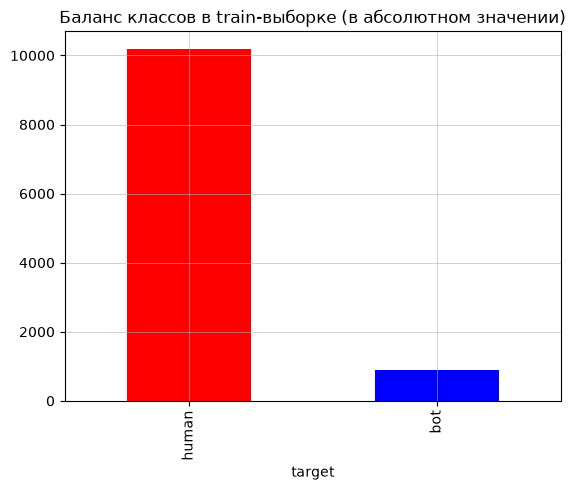

In [17]:
train_cls_b.plot(kind='bar', color=['red', 'blue'])
plt.grid(True, linewidth=0.4)
plt.title("Баланс классов в train-выборке (в абсолютном значении)")
plt.show()

`Train`-выборка имеет четко выраженный дисбаланс в пользу `human`.

##### На events-выборке

###### Без нормировки

In [18]:
events_tr_labeled = events_tr.merge(train[['cookie_id', 'target']], on='cookie_id')
events_tr_cls_b = get_class_balance(events_tr_labeled)
events_tr_cls_b

target
human    171929
bot       26507
Name: count, dtype: int64

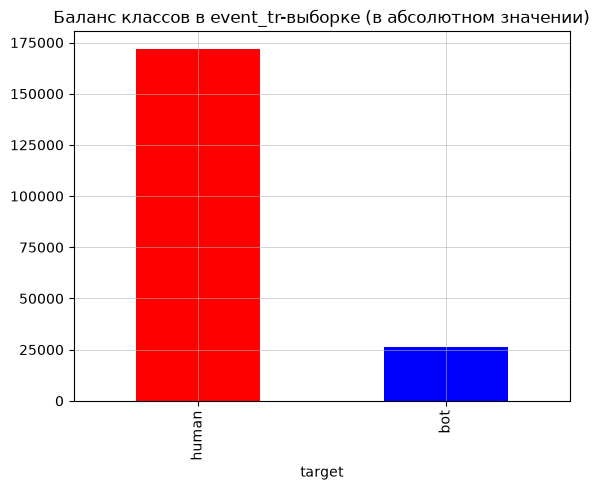

In [19]:
events_tr_cls_b.plot(kind='bar', color=['red', 'blue'])
plt.grid(True, linewidth=0.4)
plt.title("Баланс классов в event_tr-выборке (в абсолютном значении)")
plt.show()

**Наблюдения:**
- Сильный байес в пользу людей
- Возможно боты и создают ивентов интенсивнее --> попробуем отнормировать

###### log-шкала

In [20]:
log_events_tr_cls_b = np.log(events_tr_cls_b)
log_events_tr_cls_b

target
human    12.054837
bot      10.185164
Name: count, dtype: float64

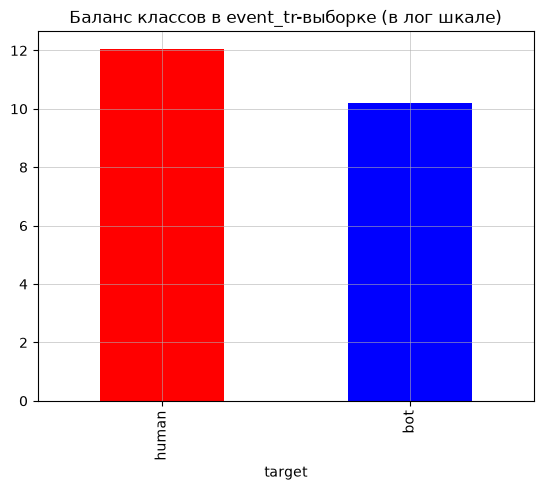

In [21]:
log_events_tr_cls_b.plot(kind='bar', color=['red', 'blue'])
plt.grid(True, linewidth=0.4)
plt.title("Баланс классов в event_tr-выборке (в лог шкале)")
plt.show()

# vvv ВЫНЕСТИ В ОТДЕЛЬНЫЙ ПУНКТ vvv

###### Среднее количество событий на куку

In [22]:
events_per_cookie = events_tr_labeled.groupby(['cookie_id', 'target']).size().rename('n_events').reset_index() # чтобы оставить target, пришлось делать и по нему группировку
avg_events_per_cookie_cls_b = events_per_cookie.groupby('target')['n_events'].mean().rename(index={0:'human', 1:'bot'})
avg_events_per_cookie_cls_b

target
human    16.869015
bot      29.484983
Name: n_events, dtype: float64

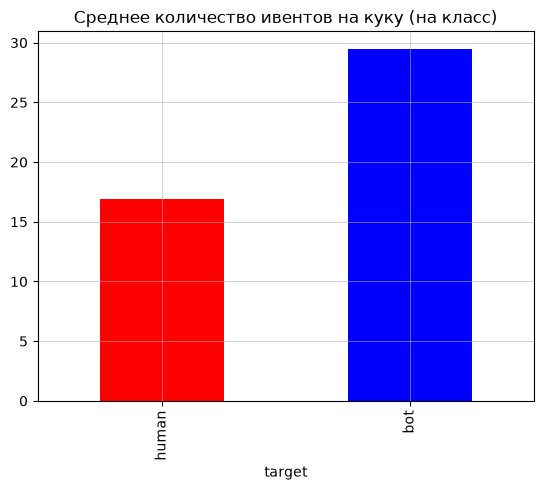

In [23]:
avg_events_per_cookie_cls_b.plot(kind='bar', color=['red', 'blue'])
plt.grid(True, linewidth=0.4)
plt.title("Среднее количество ивентов на куку (на класс)")
plt.show()

Нормировка помогла -- боты действительно генерируют больше событий (~в 2 раза больше)

#### Пропуски в данных

In [24]:
train.isna().mean().round(3)

cookie_id            0.0
cookie_created_at    0.0
window_start_ts      0.0
window_end_ts        0.0
target               0.0
dtype: float64

In [25]:
events.isna().mean().round(3)

cookie_id        0.000
event_ts         0.000
eid              0.000
event_name       0.000
platform         0.000
user_agent       0.000
item_id          0.348
item_category    0.100
item_location    0.072
seller_type      0.407
search_query     0.695
search_page      0.695
pointer_x        0.670
pointer_y        0.670
dtype: float64

In [26]:
events_tr.isna().mean().round(3)

cookie_id          0.000
event_ts           0.000
eid                0.000
event_name         0.000
platform           0.000
user_agent         0.000
item_id            0.331
item_category      0.079
item_location      0.050
seller_type        0.391
search_query       0.689
search_page        0.689
pointer_x          0.666
pointer_y          0.666
window_start_ts    0.000
window_end_ts      0.000
dtype: float64

In [27]:
events_te.isna().mean().round(3)

cookie_id          0.000
event_ts           0.000
eid                0.000
event_name         0.000
platform           0.000
user_agent         0.000
item_id            0.333
item_category      0.076
item_location      0.050
seller_type        0.392
search_query       0.687
search_page        0.687
pointer_x          0.672
pointer_y          0.672
window_start_ts    0.000
window_end_ts      0.000
dtype: float64

**Наблюдения:**
- Подозреваю, что большая часть ивентов делается ботами --> отсутствуют координаты курсора  
- Отсутствие `item_id` и/или `item_category` и/или `item_location` может судить о поиске "несуществующего" объекта??
- Пропуски разбились в равных пропорциях (для `events_tr` и `events_te`)

## Валидация

Наблюдения:
1. Необходимо соблюдать time-based сплит (из-за возможной утечки данных, в противном случае)
2. Из-за большого дисбаланса классов лучше построить сплит с расширяемым окном (иначе шумит оценка $P@R_{\ge{0.7}}$)

In [28]:
def build_time_blocks_cv(train: pd.DataFrame, n_splits: int) -> tuple[pd.Series, pd.Series]:
    '''Функция для построения валидации -- расширяемое окно на основе time-based сплита
    Проводит ленивое вычисление
    '''
    dates = np.sort(train['window_start_ts'].unique())
    blocks = np.array_split(dates, n_splits+1) #! у np.split мб ValueError из-за нецелого разбиения

    for i in range(1, n_splits + 1):
        val_mask = blocks[i]
        val_ts = train['window_start_ts'].isin(val_mask)
        train_ts = train['window_start_ts'].isin(np.concatenate(blocks[:i]))

        yield train_ts, val_ts   

In [29]:
def build_train_loop(X_train: pd.DataFrame, y_train: pd.Series, cv_split: tuple[pd.Series, pd.Series], features: list[str]) -> list[float]:
    '''Вынос логики обучения с cv в отдельную функцию
    Возвращает скоры модели по всем фолдам
    '''
    scores = []
    for idx, (train_ts, val_ts) in enumerate(cv_split):
        cbm = cb.CatBoostClassifier(
            random_state=SEED,
            iterations=ITERATIONS,
            verbose=False
        )

        cbm.fit(X_train.loc[train_ts, features], y_train[train_ts])
        proba = cbm.predict_proba(X_train.loc[val_ts, features])[:, 1]
        score = precision_at_recall(y_train[val_ts], proba)
        scores.append(score)

        print('-'*10)
        print(f"SPLIT#{idx}")
        print(f"\tsize_tr={train_ts.sum()}, size_val={val_ts.sum()}")
        print(f"\tn_bots_tr={y_train[train_ts].sum()}, n_bots_val={y_train[val_ts].sum()}")
        print(f"score={score:.4f}")

    return scores

## Бейзлайн

За основу взял `catboost` -- из-за быстрой обработки пропусков и категориальных фич.

In [30]:
def build_baseline_features(event_split: pd.DataFrame, split: pd.DataFrame) -> pd.DataFrame:
    '''Строит минимальный набор фич (для бейзлайна)
    '''
    event_split = event_split.groupby('cookie_id').agg(
        n_events = ('cookie_id', 'size'),
        n_unique_items = ('item_id', 'nunique')
    )
    return split[['cookie_id']].merge(event_split.reset_index(), on='cookie_id', how='left').fillna(0)

In [31]:
X_train = build_baseline_features(events_tr, train)
X_test = build_baseline_features(events_te, test)
y_train = train['target'].values

features_bl = ['n_events', 'n_unique_items']

X_train.shape, y_train.shape, X_test.shape

((11091, 3), (11091,), (4909, 3))

In [32]:
scores_bl = build_train_loop(
    X_train, y_train, 
    build_time_blocks_cv(train, N_SPLITS),
    features_bl
)

print('-'*10)
print(f"score.mean={np.mean(scores_bl):.4f}, score.std={np.std(scores_bl):.4f}")

----------
SPLIT#0
	size_tr=2403, size_val=2710
	n_bots_tr=197, n_bots_val=227
score=0.1092
----------
SPLIT#1
	size_tr=5113, size_val=2486
	n_bots_tr=424, n_bots_val=190
score=0.1106
----------
SPLIT#2
	size_tr=7599, size_val=2254
	n_bots_tr=614, n_bots_val=191
score=0.1365
----------
SPLIT#3
	size_tr=9853, size_val=1238
	n_bots_tr=805, n_bots_val=94
score=0.1053
----------
score.mean=0.1154, score.std=0.0123


In [33]:
model_cb = cb.CatBoostClassifier(
    random_state=SEED,
    iterations=ITERATIONS,
    verbose=100
)

model_cb.fit(X_train[features_bl], y_train)

Learning rate set to 0.019845
0:	learn: 0.6714247	total: 2.74ms	remaining: 4.1s
100:	learn: 0.2623387	total: 189ms	remaining: 2.62s
200:	learn: 0.2538578	total: 386ms	remaining: 2.49s
300:	learn: 0.2511704	total: 591ms	remaining: 2.35s
400:	learn: 0.2494182	total: 785ms	remaining: 2.15s
500:	learn: 0.2477337	total: 981ms	remaining: 1.96s
600:	learn: 0.2457728	total: 1.17s	remaining: 1.75s
700:	learn: 0.2441700	total: 1.37s	remaining: 1.56s
800:	learn: 0.2427665	total: 1.56s	remaining: 1.36s
900:	learn: 0.2413672	total: 1.76s	remaining: 1.17s
1000:	learn: 0.2400195	total: 2.02s	remaining: 1s
1100:	learn: 0.2390307	total: 2.28s	remaining: 828ms
1200:	learn: 0.2380319	total: 2.55s	remaining: 634ms
1300:	learn: 0.2370464	total: 2.81s	remaining: 430ms
1400:	learn: 0.2362221	total: 3.08s	remaining: 217ms
1499:	learn: 0.2353711	total: 3.34s	remaining: 0us


CatBoostClassifier(iterations=1500, random_state=42, verbose=100)

In [34]:
sub = pd.DataFrame({
    'cookie_id': X_test['cookie_id'],
    'score': model_cb.predict_proba(X_test[features_bl])[:, 1],
})

assert len(sub) == len(test) and sub['score'].between(0, 1).all()

sub.to_csv('submission.csv', index=False)
sub.head()

,cookie_id,score
0,ck_315fb710a0e371e7,0.024513
1,ck_a76ee3b3e3e522fd,0.056277
2,ck_94c9a4d382689e82,0.059816
3,ck_8eaf9509ad9462a0,0.056277
4,ck_9a88a5a989cb5bc6,0.027737
